c:\Users\Student\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Estimated oil price on 2013-05-12: $99.18
R-Squared: 0.7024
Mean Absolute Error: $12.17
RMSE: $13.98


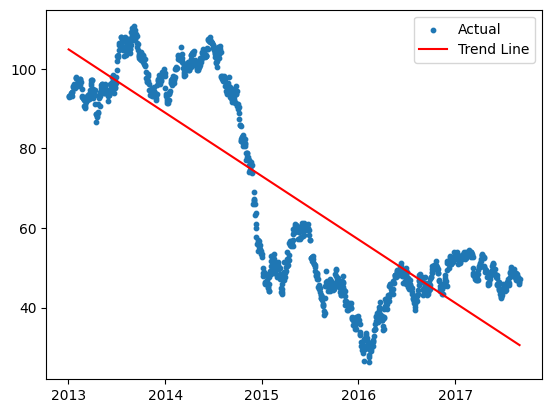

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Accessing File
df = pd.read_csv('oil.csv')
df.head()

# Clean data
df.isnull().sum() # count missing values
df = df.dropna(subset=['dcoilwtico']) # remove holidays or weekends
df['dcoilwtico'] = df['dcoilwtico'].ffill() # carry last known price forward
df['dcoilwtico'] = df['dcoilwtico'].fillna(df['dcoilwtico'].mean()) #fill missing values with mean

# Clean and convert dates
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')     # Sort the values of dates
df.set_index('date',inplace=True)
df['dcoilwtico'] = df['dcoilwtico'].astype(float)
df.head()


# Convert to ordinal for regression
df['DateOrdinal'] = df.index.map(datetime.toordinal) # Convert each date into a number and storing

# Model
model = LinearRegression()
X = df[['DateOrdinal']]
y = df[['dcoilwtico']]
model.fit(X,y)

LinearRegression()

#Prediction Fuction
def predict_price(date):                  # expects string representing date
    try:
        input_date = datetime.strptime(date,"%Y-%m-%d")
        input_ordinal = np.array([[input_date.toordinal()]])  # Handle thousands of rows at once "matrix" with 1 row and 1 column
        predicted_price = model.predict(input_ordinal)[0][0]  # Flattening prediction with [0][0] to drill down into the actual value
        return round(float(predicted_price),2)
    except Exception as e:
        return f"Error: {e}"
    
user_input = input("Enter a date(YYY-MM-DD):")
predicted_price = predict_price(user_input)
print(f"Estimated oil price on {user_input}: ${predicted_price}")



# Model evaluation 
# 1. Goodness of fit: Tells us the percentage of the oil price variance explained by date column
# 2. Mean Absolute Error: Tells us on average how faulty is our prediction (in dollars)
# 3. Root mean Square: Identify if model is failing badly on specific spikes

prediction = model.predict(X)  # Predictions for existing data

mae = mean_absolute_error(y, prediction)
rmse = np.sqrt(mean_squared_error(y,prediction))
r2 = r2_score(y, prediction)

print(f"R-Squared: {r2:.4f}")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")

# Error analyses
plt.scatter(df.index, y, label='Actual', s=10)
plt.plot(df.index, prediction, color='red', label='Trend Line')
plt.legend()
plt.show()





